In [1]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt
from testCases_v2 import *
import sklearn
import sklearn.datasets
import sklearn.linear_model
from planar_utils import plot_decision_boundary, sigmoid, load_planar_dataset, load_extra_datasets

%matplotlib inline

np.random.seed(1) # set a seed so that the results are consistent

In [2]:
X, y = load_planar_dataset()

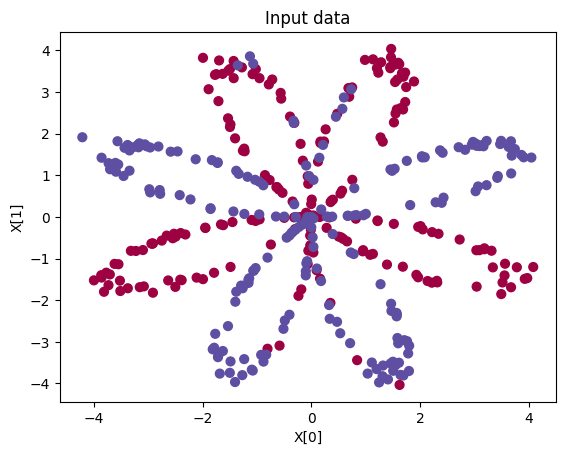

In [3]:
plt.scatter(X[0, :], X[1, :], c=y, s=40, cmap=plt.cm.Spectral)
plt.title("Input data")
plt.xlabel("X[0]")
plt.ylabel("X[1]")
plt.show()

In [4]:
shape_X = X.shape
shape_y = y.shape
m = shape_X[1]
print(f"X.shape: {shape_X}")
print(f"y.shape: {shape_y}")
print(f"Number of training examples: {m}")

X.shape: (2, 400)
y.shape: (1, 400)
Number of training examples: 400


/home/nafiz/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


w: [[ 0.02780872 -0.20164061]]
b: [0.01542522]


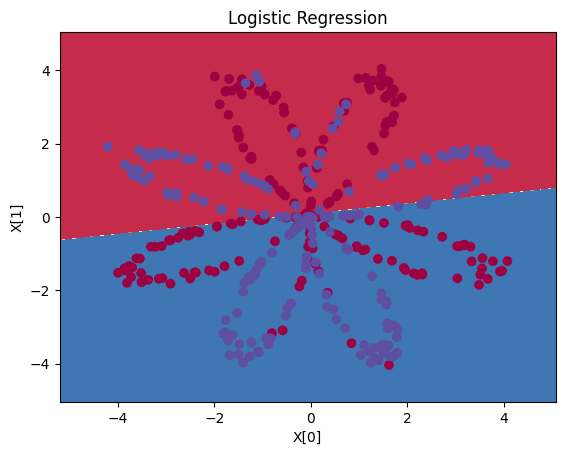

Training accuracy: 0.47


/tmp/ipykernel_78449/452172449.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  accuracy = float(np.dot(y, predictions) + np.dot(1 - y, 1 - predictions)) / m


In [5]:
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X.T, y.T)
print(f"w: {clf.coef_}")
print(f"b: {clf.intercept_}")
# Plot the decision boundary
plot_decision_boundary(lambda x: clf.predict(x), X, y)
plt.title("Logistic Regression")
plt.xlabel("X[0]")
plt.ylabel("X[1]")
plt.show()
# Compute the accuracy on the training set
predictions = clf.predict(X.T)
accuracy = float(np.dot(y, predictions) + np.dot(1 - y, 1 - predictions)) / m
print(f"Training accuracy: {accuracy}")

In [6]:
def layer_sizes(X, y):
    n_x = X.shape[0] # size of input layer
    n_h = 4 # size of hidden layer (arbitrary choice)
    n_y = y.shape[0] # size of output layer
    return (n_x, n_h, n_y)

In [7]:
n_x, n_h, n_y = layer_sizes(X, y)
print(f"n_x: {n_x}")
print(f"n_h: {n_h}")
print(f"n_y: {n_y}")

n_x: 2
n_h: 4
n_y: 1


In [8]:
def initialize_parameters(n_x, n_h, n_y):
    w1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    w2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    parameters = {"w1": w1, "b1": b1, "w2": w2, "b2": b2}
    return parameters

In [10]:
parameters = initialize_parameters(n_x, n_h, n_y)
print("W1 = " + str(parameters["w1"]))
print("b1 = " + str(parameters["b1"]))
print("W2 = " + str(parameters["w2"]))
print("b2 = " + str(parameters["b2"]))

W1 = [[ 0.00132248 -0.00563237]
 [ 0.02390146  0.00245423]
 [ 0.01152599 -0.00224236]
 [-0.00326061 -0.00030911]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
W2 = [[ 0.00355717  0.00849587 -0.00122154 -0.00680852]]
b2 = [[0.]]


In [11]:
def forward_propagation(X, parameters):
    w1 = parameters["w1"]
    b1 = parameters["b1"]
    w2 = parameters["w2"]
    b2 = parameters["b2"]

    z1 = np.dot(w1, X) + b1
    a1 = np.tanh(z1)
    z2 = np.dot(w2, a1) + b2
    a2 = sigmoid(z2)

    cache = {"z1": z1, "a1": a1, "z2": z2, "a2": a2}
    return a2, cache

In [15]:
A2, cache = forward_propagation(X, parameters)
print(np.mean(cache['z1']) ,np.mean(cache['a1']),np.mean(cache['z2']),np.mean(cache['a2']))

-0.0004611201195774574 -0.0004606437051345735 -8.95732813320564e-06 0.4999977606680632


In [17]:
def compute_cost(a2, y, parameters):
    m = y.shape[1] # number of examples
    logprobs = np.multiply(np.log(a2), y) + np.multiply(np.log(1 - a2), 1 - y)
    cost = -np.sum(logprobs) / m
    cost = float(np.squeeze(cost)) # makes sure cost is the dimension we expect
    return cost